<a href="https://colab.research.google.com/github/astgregory/Task_16-OpenCV_FaceRecognition/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D1%8F%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9616.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

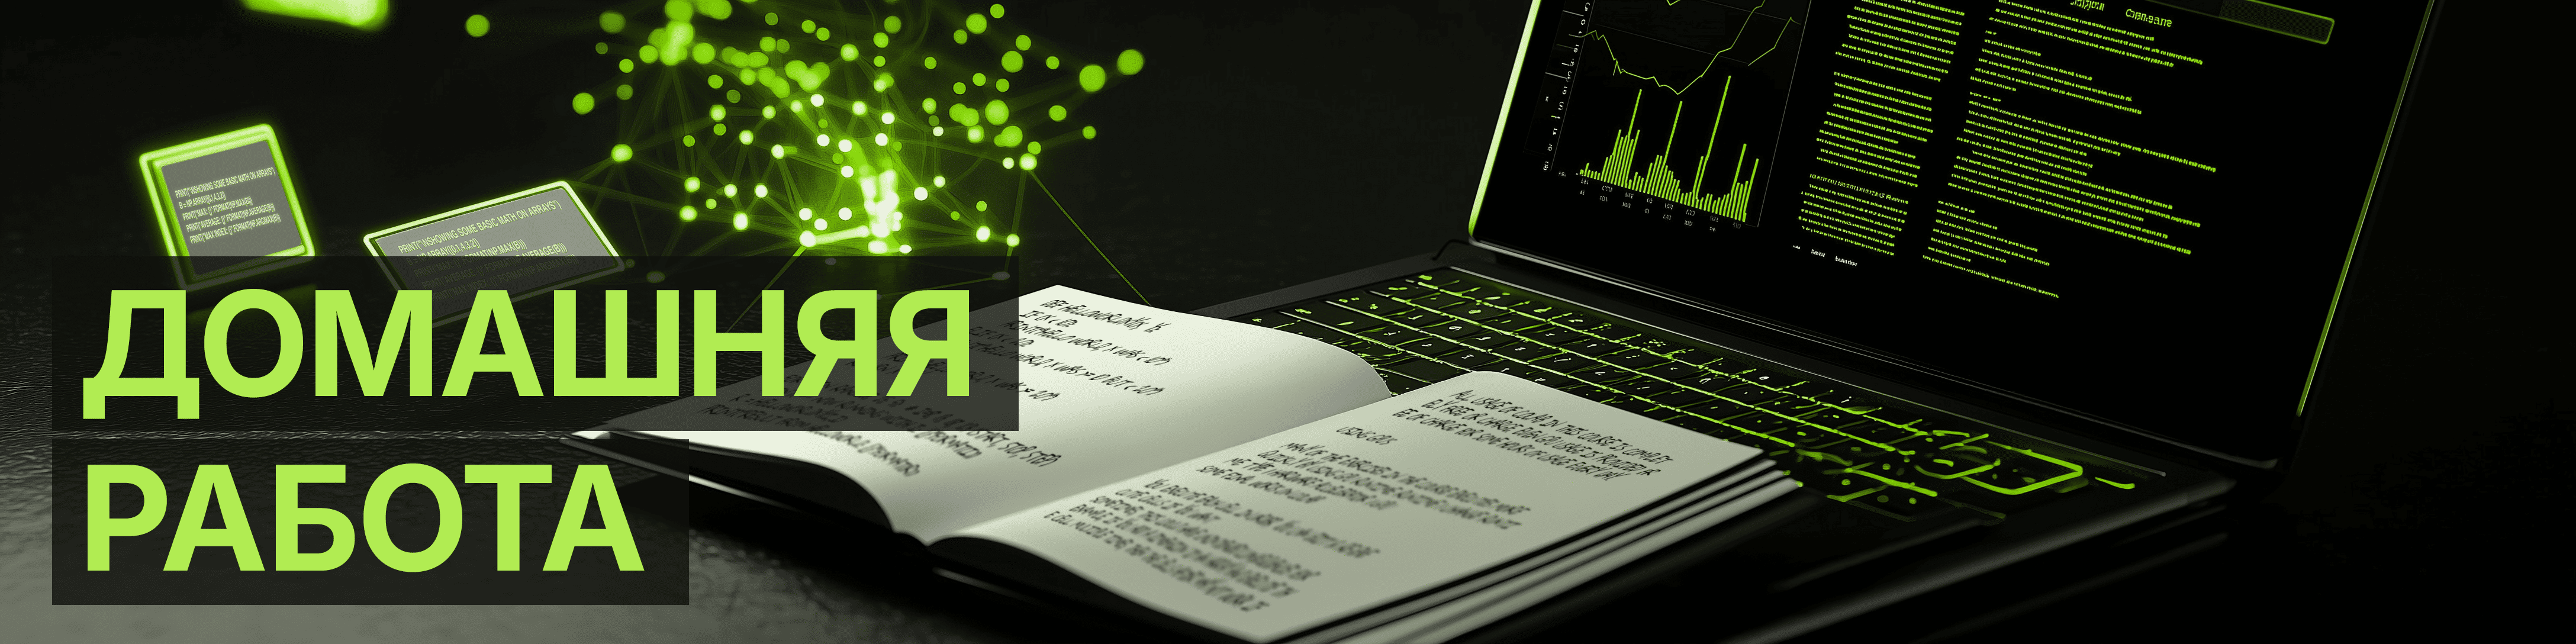

**Навигация по уроку**

1. [Задачи машинного зрения на OpenCV](https://colab.research.google.com/drive/1x1rxbNfV1ft1ztIPwxA3q34J4MULix5A)
2. [OpenCV. Распознавание лиц (практика)](https://colab.research.google.com/drive/1GwMZ8BAjtdKBDA5S0lAX1OPMFmIaYhqL)
3. Домашняя работа


Используя знания из практической части урока и функцию `blur_face` (размытие), проведите следующий эксперимент:
1. Найдите фото любого известного актера или актрисы.
2. Распознайте лицо на фотографии. Выделите лицо овалом. Какой метод для рисования овала использовать, вы должны найти самостоятельно.
3. Выделите на изображении глаза. Выделите их кружком. Если вы чувствуете в себе суперсилу и дополнительный бекграунд знаний, и хотите получить больше баллов за задание, то нарисуйте вместо кружков солнцезащитные очки (картинку очков можно найти в интернете, задача их правильно масштабировать и разместить).
4. Все лицо кроме глаз необходимо "заблюрить" (размыть) с помощью функции `blur_face` (функция объявлена ниже).




Оценка за задание:
* 1 балл - задача решена с помощью куратора, лицо распознано прямоугольником, глаза кругом.
* 2 балла - задача решена с незначительными подсказками куратора, лицо распознано прямоугольником или кругом, глаза кругом, лицо размыто.
* 3 балла - задача решена самостоятельно, лицо распознано овалом, глаза кругом, удалось заблюрить лицо, не затронув глаза.
* 4 балла - задача решена самостоятельно на 3 балла, удалось нарисовать очки с подсказкой куратора, недостаточна соблюдена симметрия расположения очков или недостаточно учтены их размеры.
* 5 баллов - задача полностью решена самостоятельно, все пункты выполнены.

In [ ]:
import cv2

def blur_face(img):
  (h, w) = img.shape[:2]
  dW = int(w / 3.0)
  dH = int(h / 3.0)
  if dW % 2 == 0:
      dW -= 1
  if dH % 2 == 0:
      dH -= 1
  return cv2.GaussianBlur(img, (dW, dH), 0)

# **1. Разпознование лица овалом и глаз, наложение очков**

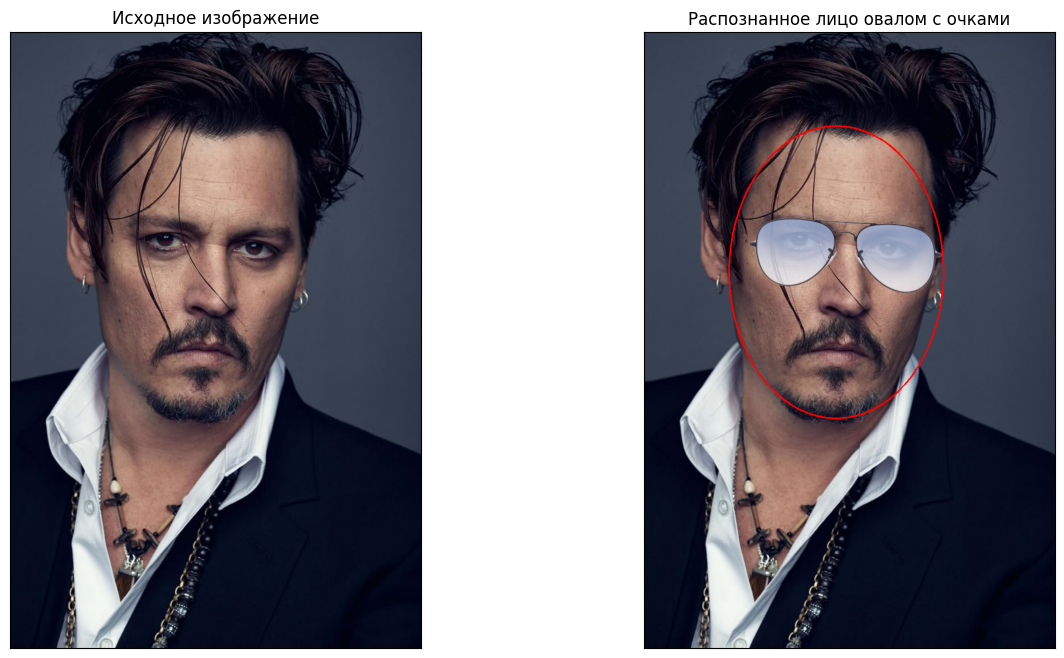

In [ ]:
import cv2
import gdown
import numpy as np
from matplotlib import pyplot
# Команда обеспечивает вывод графиков в Google Colaboratory
%matplotlib inline

gdown.download('https://i.pinimg.com/736x/91/ee/41/91ee41005c95e6830fd1b5d76da15c74.jpg', None, quiet=True)
gdown.download('https://wallpapers.com/images/hd/classic-aviator-sunglasses-transparent-background-3rmi08u2j4mdwtkq.png', None, quiet=True)

# Загрузка изображения
img = cv2.imread('./91ee41005c95e6830fd1b5d76da15c74.jpg')
img2 = img.copy()

glasses_img = cv2.imread('./classic-aviator-sunglasses-transparent-background-3rmi08u2j4mdwtkq.png', cv2.IMREAD_UNCHANGED)

# загрузка каскада Хаара для поиска лиц
classifier_face = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_frontalface_default.xml")


# загрузка каскада Хаара для поиска глаз
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_eye.xml")

# выполнение распознавания лиц
bboxes = classifier_face.detectMultiScale(img, scaleFactor=2, minNeighbors=3, minSize=(50, 50))

# формирование овала вокруг каждого обнаруженного лица
for box in bboxes:
    # формирование координат
    x, y, width, height = box
    center = (x + width // 2 - 10, y + height // 2)
    axes = (width // 2, height // 2 + 70)
    angle = 0
    color = (0, 0, 255)
    thickness = 2

    # рисование овала
    cv2.ellipse(img2, center, axes, angle, 0, 360, color, thickness)

    face = img2[y:y + height, x:x + width]

    # выполнение распознавания глаз
    eyes = classifier_eye.detectMultiScale(face)

    if len(eyes) >= 2:

        (ex1, ey1, ew1, eh1), (ex2, ey2, ew2, eh2) = eyes[0], eyes[1]

        #наложение очков
        gx = (x + ex1 + ew1 // 2 + x + ex2 + ew2 // 2) // 2
        gy = (y + ey1 + eh1 // 2 + y + ey2 + eh2 // 2) // 2

        glasses_width = ex1 + ew1 - ex2 + 100
        glasses_height = int(glasses_width * glasses_img.shape[0] / glasses_img.shape[1])

        glasses_mask_small = cv2.resize(glasses_img, (glasses_width, glasses_height), interpolation=cv2.INTER_AREA)

        M = cv2.getAffineTransform(
            np.float32([[0, 0], [glasses_width, 0], [0, glasses_height]]),
                        np.float32([[0, 0], [glasses_width, 20], [0, glasses_height]]))

        glasses_mask_small = cv2.warpAffine(glasses_mask_small, M,
                                             (glasses_width, glasses_height + 20))

        y_offset = gy - glasses_height // 2 + 10
        x_offset = gx - glasses_width // 2 + 10


        for c in range(0, 3):
            img2[y_offset:y_offset + glasses_height + 20,
                 x_offset:x_offset + glasses_width, c] = \
                 glasses_mask_small[..., c] * (glasses_mask_small[..., 3] / 255.0) + \
                 img2[y_offset:y_offset + glasses_height + 20, x_offset:x_offset + glasses_width, c] * (1 - glasses_mask_small[..., 3] / 255.0)

fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Исходное изображение')

ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Распознанное лицо овалом с очками')

pyplot.show()


# **2. Размытие лица, кроме глаз**

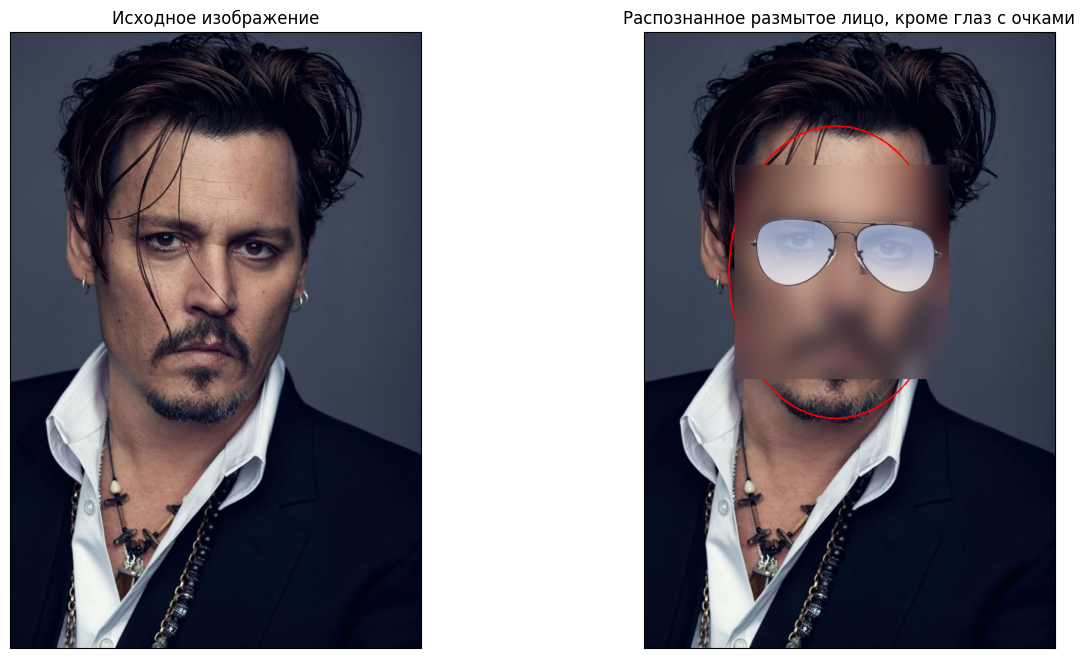

In [ ]:
import cv2
import gdown
import numpy as np
from matplotlib import pyplot
# Команда обеспечивает вывод графиков в Google Colaboratory
%matplotlib inline

# Загрузка изображений
gdown.download('https://i.pinimg.com/736x/91/ee/41/91ee41005c95e6830fd1b5d76da15c74.jpg', None, quiet=True)
gdown.download('https://wallpapers.com/images/hd/classic-aviator-sunglasses-transparent-background-3rmi08u2j4mdwtkq.png', None, quiet=True)

img = cv2.imread('./91ee41005c95e6830fd1b5d76da15c74.jpg')
img2 = img.copy()

glasses_img = cv2.imread('./classic-aviator-sunglasses-transparent-background-3rmi08u2j4mdwtkq.png', cv2.IMREAD_UNCHANGED)

# загрузка каскада Хаара для поиска лиц и глаз
classifier_face = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

# выполнение распознавания лиц
bboxes = classifier_face.detectMultiScale(img, scaleFactor=2, minNeighbors=3, minSize=(50, 50))

# формирование овала вокруг каждого обнаруженного лица
for box in bboxes:
    # формирование координат
    x, y, width, height = box
    center = (x + width // 2 - 10, y + height // 2)
    axes = (width // 2, height // 2 + 70)
    angle = 0
    color = (0, 0, 255)
    thickness = 2

    # рисование овала
    cv2.ellipse(img2, center, axes, angle, 0, 360, color, thickness)
    face = img2[y:y + height, x:x + width]

    # выполнение распознавания глаз
    eyes = classifier_eye.detectMultiScale(face)

    #Маска для размытия
    mask = np.zeros_like(face, dtype=np.uint8)

    if len(eyes) >= 2:
        (ex1, ey1, ew1, eh1), (ex2, ey2, ew2, eh2) = eyes[0], eyes[1]

        mask[ey1:ey1 + eh1, ex1:ex1 + ew1] = face[ey1:ey1 + eh1, ex1:ex1 + ew1]
        mask[ey2:ey2 + eh2, ex2:ex2 + ew2] = face[ey2:ey2 + eh2, ex2:ex2 + ew2]

        # Размытие лица
        blurred_face = blur_face(face)
        combined_face = np.where(mask == 0, blurred_face, face)
        img2[y:y + height, x:x + width] = combined_face

        #наложение очков
        gx = (x + ex1 + ew1 // 2 + x + ex2 + ew2 // 2) // 2
        gy = (y + ey1 + eh1 // 2 + y + ey2 + eh2 // 2) // 2

        glasses_width = ex1 + ew1 - ex2 + 100
        glasses_height = int(glasses_width * glasses_img.shape[0] / glasses_img.shape[1])

        glasses_mask_small = cv2.resize(glasses_img, (glasses_width, glasses_height), interpolation=cv2.INTER_AREA)

        M = cv2.getAffineTransform(
            np.float32([[0, 0], [glasses_width, 0], [0, glasses_height]]),

                        np.float32([[0, 0], [glasses_width, 20], [0, glasses_height]]))

        glasses_mask_small = cv2.warpAffine(glasses_mask_small, M,
                                             (glasses_width, glasses_height + 20))

        y_offset = gy - glasses_height // 2 + 10
        x_offset = gx - glasses_width // 2 + 10

        for c in range(0, 3):
            img2[y_offset:y_offset + glasses_height + 20,
                 x_offset:x_offset + glasses_width, c] = \
                 glasses_mask_small[..., c] * (glasses_mask_small[..., 3] / 255.0) + \
                 img2[y_offset:y_offset + glasses_height + 20, x_offset:x_offset + glasses_width, c] * (1 - glasses_mask_small[..., 3] / 255.0)


fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Исходное изображение')

ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Распознанное размытое лицо, кроме глаз с очками')

pyplot.show()
